C:\Users\nguye\AppData\Local\Temp\ipykernel_18816\3560894124.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


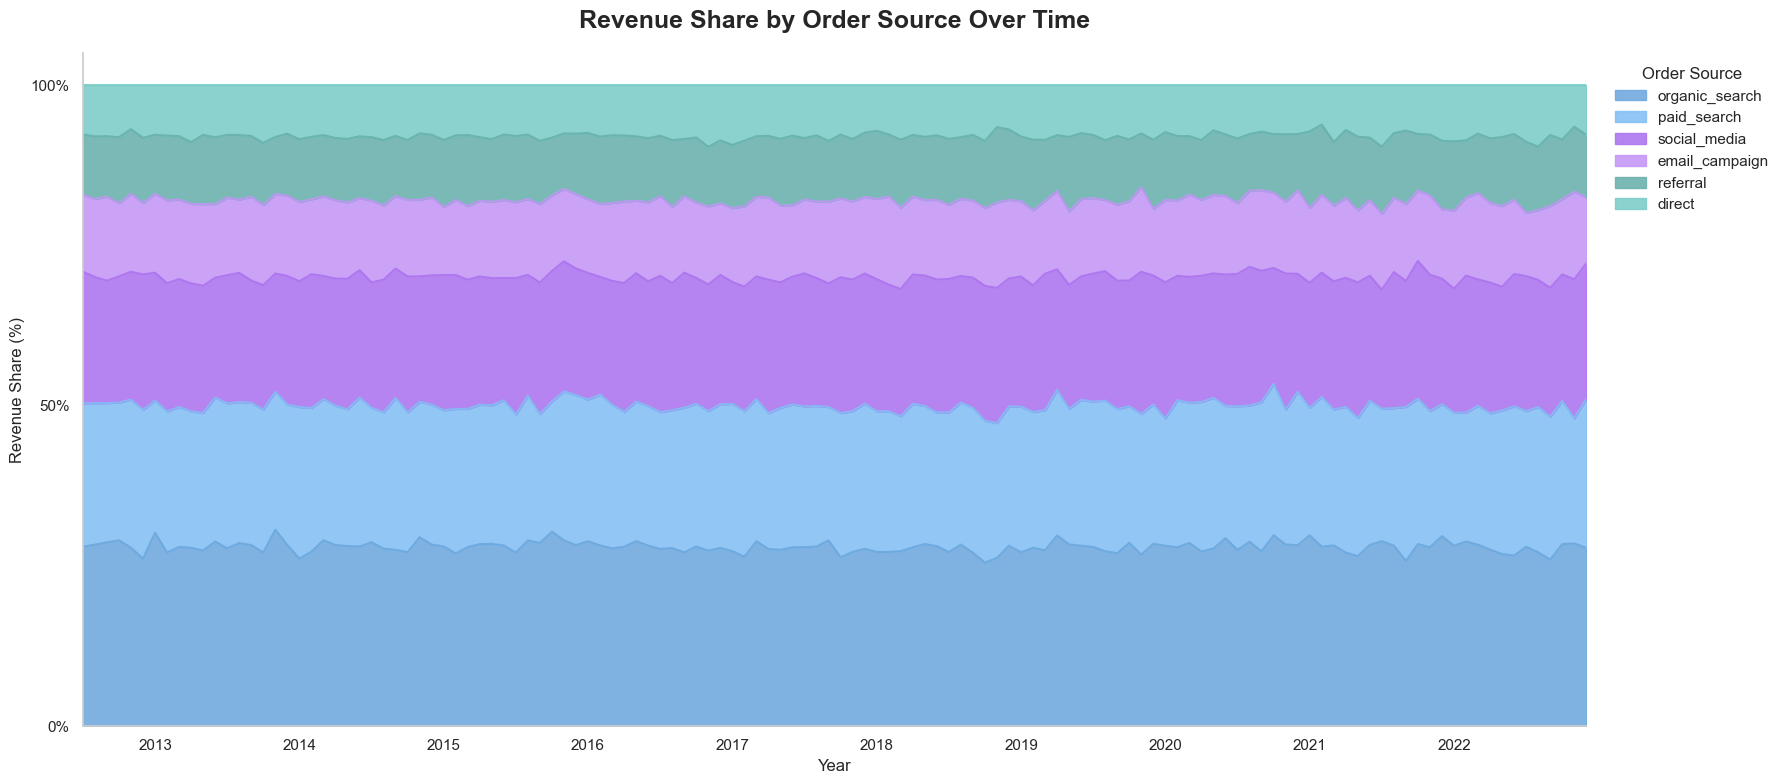

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv("../data/order_items.csv")

# Compute revenue
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"]
    - order_items["discount_amount"]
)

# Merge order source
df = order_items.merge(
    orders[["order_id", "order_date", "order_source"]],
    on="order_id",
    how="left"
)

# Aggregate by month and order source
df["month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_revenue = (
    df.groupby(["month", "order_source"])["revenue"]
    .sum()
    .reset_index()
)

# Pivot table
pivot = monthly_revenue.pivot(
    index="month",
    columns="order_source",
    values="revenue"
).fillna(0)

# Sort sources by total revenue
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

# Convert revenue to revenue share
pivot_share = pivot.div(pivot.sum(axis=1), axis=0)

# Colors
colors = [
    "#6DA8DD",
    "#82BFF4",
    "#AC73EE",
    "#C396F7",
    "#68B0AC",
    "#7BCCC8",
]

assert len(colors) == pivot_share.shape[1], "Số màu không khớp với số lượng order_source"

# Export data to CSV
pivot_share.reset_index().to_csv(
    "../data/revenue_share_by_order_source.csv",
    index=False
)

# Plot
fig, ax = plt.subplots(figsize=(18, 8))

pivot_share.plot.area(
    ax=ax,
    alpha=0.88,
    color=colors
)

ax.set_title(
    "Revenue Share by Order Source Over Time",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year")
ax.set_ylabel("Revenue Share (%)")

# Y-axis: 0%, 50%, 100%
ax.set_yticks([0, 0.5, 1])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# X-axis: chỉ hiển thị năm
year_ticks = pivot_share.index[pivot_share.index.month == 1]

ax.set_xticks(year_ticks)
ax.set_xticklabels(
    [d.strftime("%Y") for d in year_ticks],
    rotation=0
)

ax.legend(
    title="Order Source",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

pivot_share.to_csv("db4-data/revenue_share_by_order_source.csv")

C:\Users\nguye\AppData\Local\Temp\ipykernel_18816\942819088.py:21: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([traffic_ts, orders_ts], axis=1)


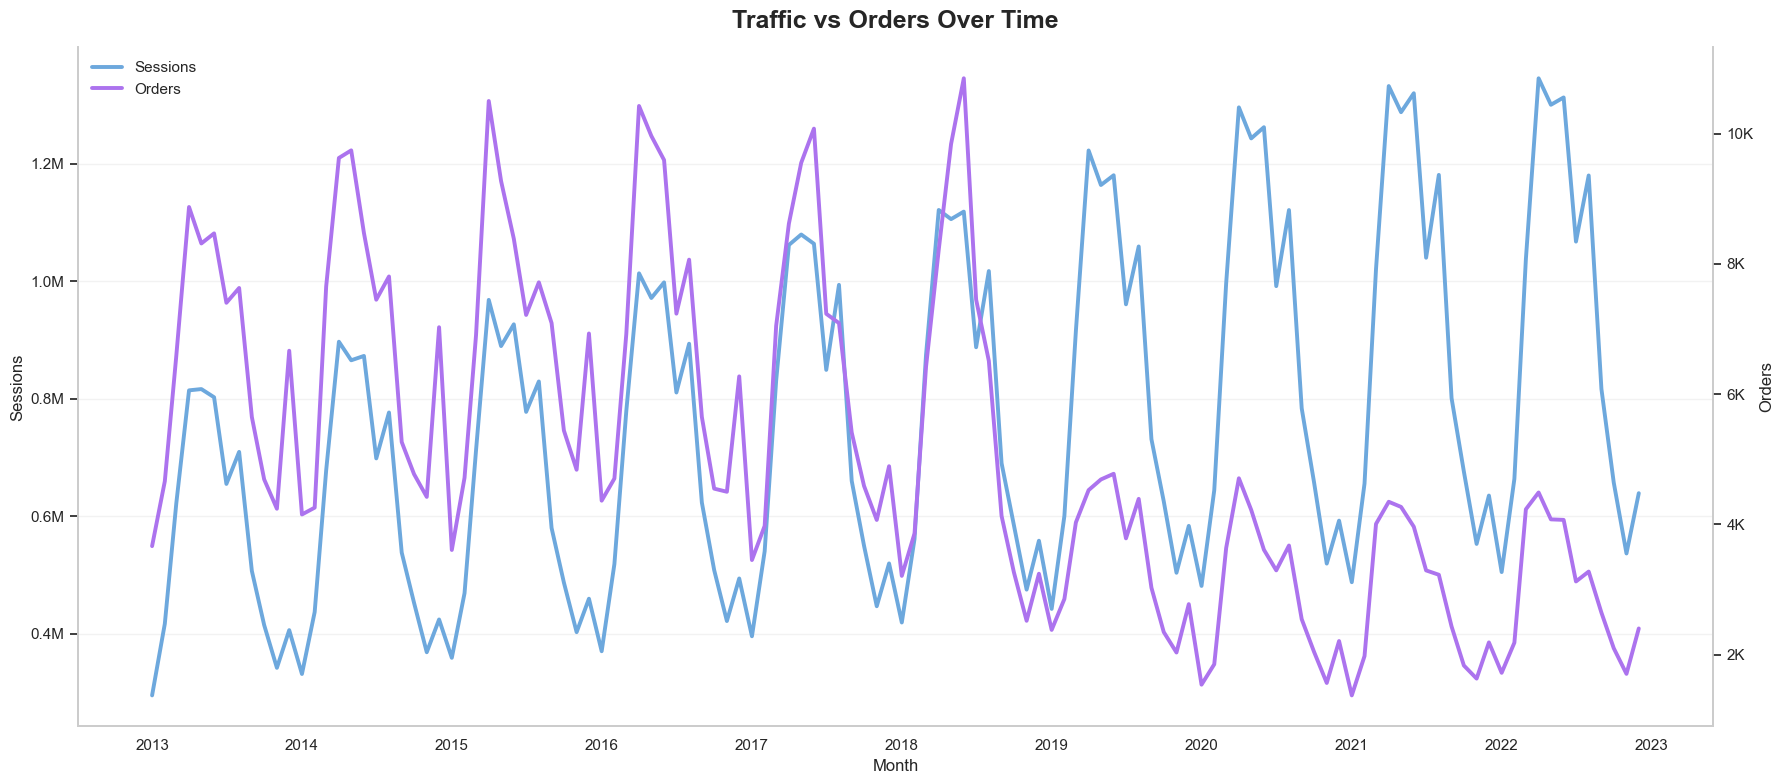

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# Load data
traffic = pd.read_csv("../data/web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])

# Monthly traffic
traffic["month"] = traffic["date"].dt.to_period("M").dt.to_timestamp()
traffic_ts = traffic.groupby("month")["sessions"].sum()

# Monthly orders
orders["month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()
orders_ts = orders.groupby("month")["order_id"].nunique()

# Combine
df = pd.concat([traffic_ts, orders_ts], axis=1)
df.columns = ["sessions", "orders"]
df = df.dropna()

# Plot dual-axis
fig, ax1 = plt.subplots(figsize=(18, 8))

# Left axis: Sessions
ax1.plot(
    df.index,
    df["sessions"],
    color="#6DA8DD",
    linewidth=2.8,
    label="Sessions"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sessions")
ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

# Right axis: Orders
ax2 = ax1.twinx()

ax2.plot(
    df.index,
    df["orders"],
    color="#AC73EE",
    linewidth=2.8,
    label="Orders"
)

ax2.set_ylabel("Orders")
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1_000:.0f}K")
)

# Title
ax1.set_title(
    "Traffic vs Orders Over Time",
    fontsize=18,
    fontweight="bold",
    pad=14
)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=False
)

# Style
ax1.grid(axis="y", alpha=0.25)
ax1.grid(axis="x", visible=False)
ax2.grid(False)

sns.despine(right=False)

plt.tight_layout()
plt.show()

df.to_csv("db4-data/traffic_orders_monthly.csv", index=True)

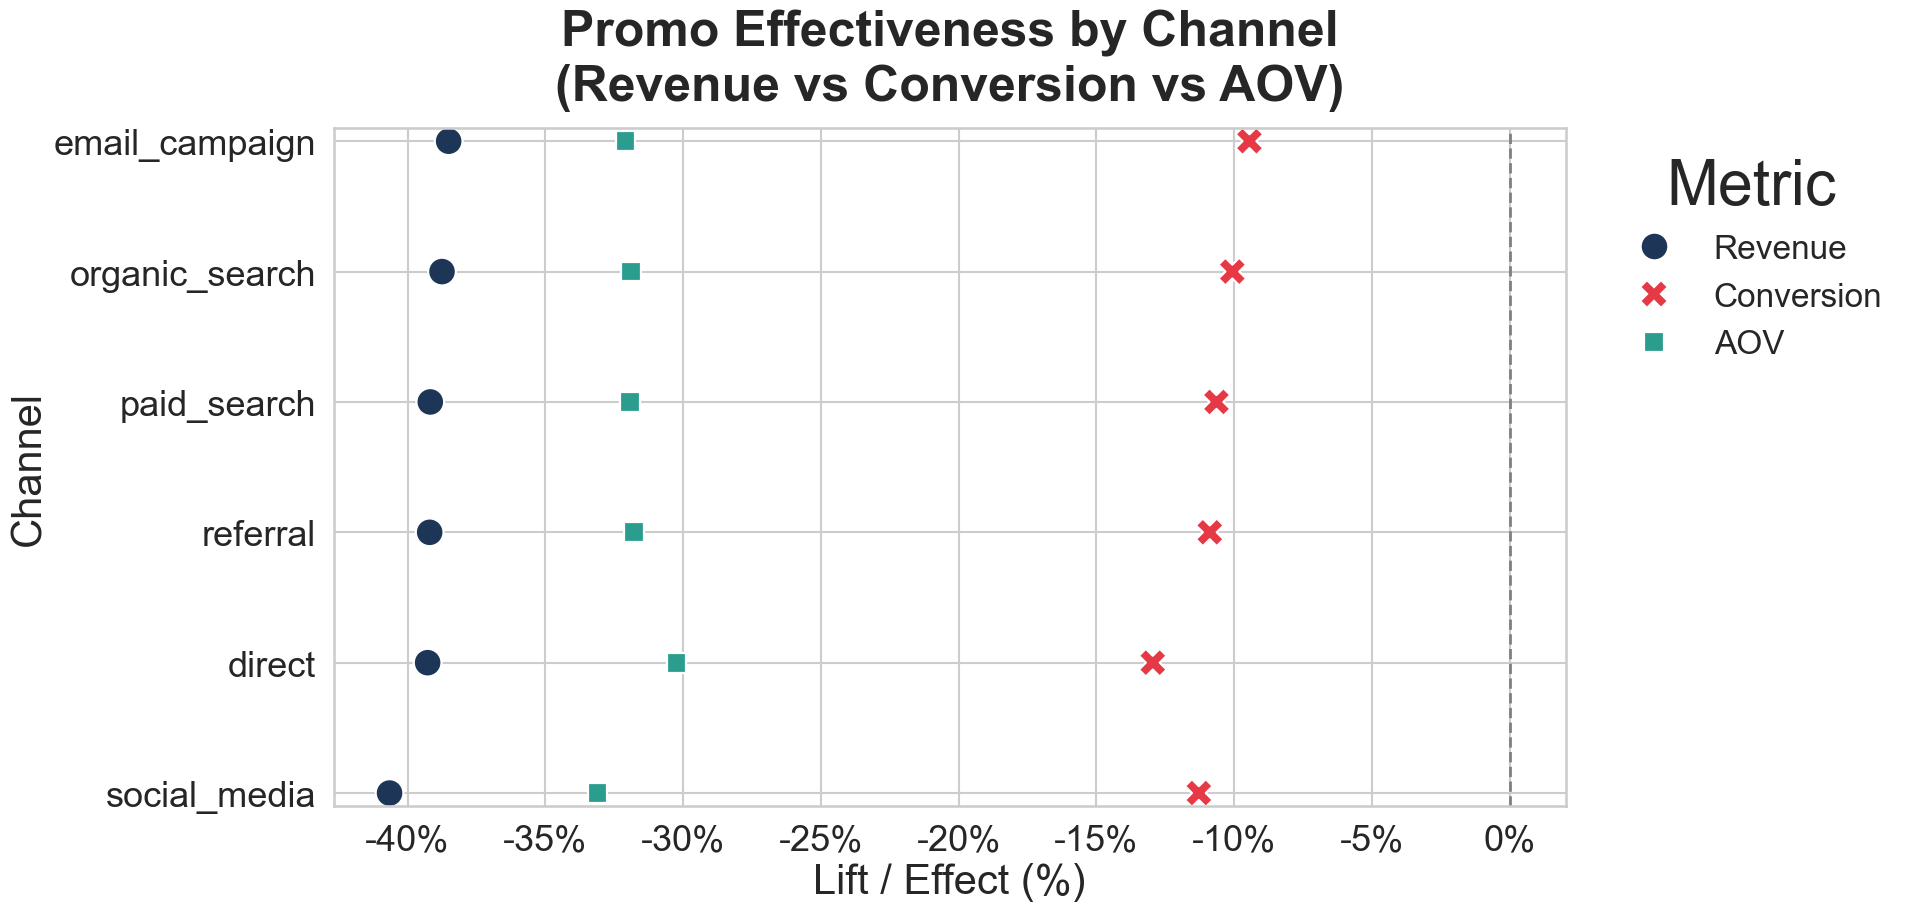

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# =========================
# Style (font to + clean)
# =========================
sns.set(style="whitegrid")
sns.set_context("talk", font_scale=2.5)  # tăng toàn bộ font

plt.rcParams.update({
    "font.size": 36,
    "axes.titlesize": 36,
    "axes.labelsize": 30,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 24
})

# =========================
# reshape data
# =========================
plot_df = metrics_df.melt(
    id_vars="order_source",
    value_vars=["revenue_lift", "conversion_lift", "aov_effect"],
    var_name="metric",
    value_name="value"
)

metric_map = {
    "revenue_lift": "Revenue",
    "conversion_lift": "Conversion",
    "aov_effect": "AOV"
}

plot_df["metric"] = plot_df["metric"].map(metric_map)

plot_df.to_csv('plot_df.csv', index= True)

# =========================
# plot
# =========================
plt.figure(figsize=(20, 10))  # rộng hơn

sns.scatterplot(
    data=plot_df,
    x="value",
    y="order_source",
    hue="metric",
    style="metric",
    s=400,  # 🔥 tăng size icon
    palette=["#1D3557", "#E63946", "#2A9D8F"]  # dễ phân biệt hơn
)

# zero line
plt.axvline(0, linestyle="--", color="gray", linewidth=2)

# giảm khoảng cách giữa các dòng
plt.gca().margins(y=0.02)

# format
plt.title(
    "Promo Effectiveness by Channel\n(Revenue vs Conversion vs AOV)",
    fontweight="bold",
    pad=20
)

plt.xlabel("Lift / Effect (%)")
plt.ylabel("Channel")

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()



C:\Users\nguye\AppData\Local\Temp\ipykernel_18816\3745727852.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


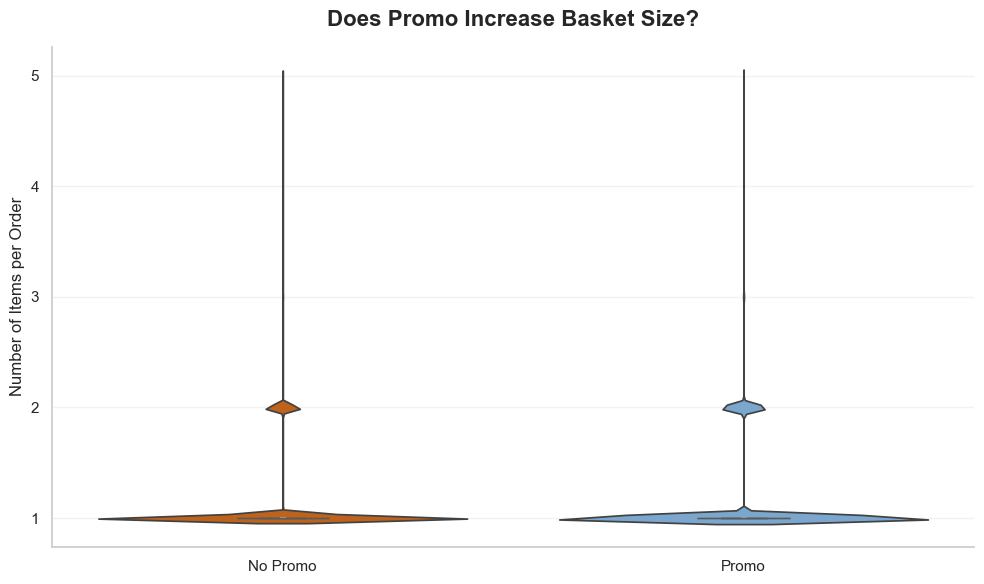

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# =========================
# Prepare data (OPTIMIZED)
# =========================

# Vectorized promo flag + single groupby
df = (
    order_items.assign(
        is_promo = order_items[["promo_id", "promo_id_2"]].notna().any(axis=1)
    )
    .groupby("order_id")
    .agg(
        items_per_order=("product_id", "nunique"),  # đổi thành "size" nếu product_id đã unique
        is_promo=("is_promo", "any")
    )
    .reset_index()
)

# Label
df["promo_group"] = df["is_promo"].map({
    True: "Promo",
    False: "No Promo"
})

# =========================
# Plot
# =========================

# Nếu data rất lớn → sample để plot nhanh hơn
# df = df.sample(50000, random_state=42)

plt.figure(figsize=(18, 8))

sns.violinplot(
    data=df,
    x="promo_group",
    y="items_per_order",
    palette=["#D95F02", "#6DA8DD"]
)

sns.boxplot(
    data=df,
    x="promo_group",
    y="items_per_order",
    width=0.2,
    showcaps=True,
    boxprops={'facecolor': 'white'},
    showfliers=False
)

plt.title(
    "Does Promo Increase Basket Size?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("")
plt.ylabel("Number of Items per Order")

plt.grid(axis="y", alpha=0.25)
sns.despine()

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import plotly.graph_objects as go

# =========================
# Prepare order-level promo flag
# =========================
orders_df = orders.copy()
items_df = order_items.copy()

orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

promo_cols = [c for c in ["promo_id", "promo_id_2"] if c in items_df.columns]

if "discount_amount" in items_df.columns:
    items_df["has_discount"] = items_df["discount_amount"].fillna(0) > 0
else:
    items_df["has_discount"] = False

items_df["has_promo_id"] = False
for col in promo_cols:
    items_df["has_promo_id"] = items_df["has_promo_id"] | items_df[col].notna()

items_df["is_promo_item"] = items_df["has_promo_id"] | items_df["has_discount"]

order_promo = (
    items_df.groupby("order_id")["is_promo_item"]
    .any()
    .reset_index(name="is_promo_order")
)

df = orders_df.merge(order_promo, on="order_id", how="left")
df["is_promo_order"] = df["is_promo_order"].fillna(False)

# =========================
# Customer purchase sequence
# =========================
df = df.sort_values(["customer_id", "order_date", "order_id"])

df["purchase_no"] = (
    df.groupby("customer_id")
    .cumcount() + 1
)

df = df[df["purchase_no"].isin([1, 2, 3])]

df["stage_label"] = df.apply(
    lambda x: f"Purchase {x['purchase_no']}: " + ("Promo" if x["is_promo_order"] else "No Promo"),
    axis=1
)

seq = (
    df.pivot_table(
        index="customer_id",
        columns="purchase_no",
        values="stage_label",
        aggfunc="first"
    )
    .reset_index()
)

seq = seq.rename(columns={
    1: "purchase_1",
    2: "purchase_2",
    3: "purchase_3"
})

seq["purchase_2"] = seq["purchase_2"].fillna("No 2nd Purchase")
seq["purchase_3"] = seq["purchase_3"].fillna("No 3rd Purchase")

# =========================
# Build Sankey links
# =========================
links_12 = (
    seq.groupby(["purchase_1", "purchase_2"])
    .size()
    .reset_index(name="value")
)

links_23 = (
    seq.groupby(["purchase_2", "purchase_3"])
    .size()
    .reset_index(name="value")
)

links = pd.concat([
    links_12.rename(columns={"purchase_1": "source", "purchase_2": "target"}),
    links_23.rename(columns={"purchase_2": "source", "purchase_3": "target"})
])

labels = pd.unique(links[["source", "target"]].values.ravel()).tolist()
label_to_id = {label: i for i, label in enumerate(labels)}

links["source_id"] = links["source"].map(label_to_id)
links["target_id"] = links["target"].map(label_to_id)

# =========================
# Color logic
# =========================

warm_colors = [
    "#E63946",  # đỏ
    "#FF6B6B",  # đỏ nhạt
    "#F77F00",  # cam
    "#FFB703"   # vàng cam
]

promo_blues = [
    "#004AAD",  # xanh đậm
    "#38B6FF",
    "#0CC0DF"
]

light_colors = [
    "#00BF63",
    "#7ED957",
    "#C1FF72"
]

label_colors = {}

warm_idx = 0
promo_idx = 0
light_idx = 0

for label in labels:
    # 🔴 Drop-off (ưu tiên cao nhất)
    if "No 2nd Purchase" in label or "No 3rd Purchase" in label:
        label_colors[label] = warm_colors[warm_idx % len(warm_colors)]
        warm_idx += 1

    # 🔵 Promo → xanh đậm
    elif "No Promo" in label:
        label_colors[label] = promo_blues[promo_idx % len(promo_blues)]
        promo_idx += 1

    # 🟢/🔹 No Promo → xanh nhạt (blue + green mix)
    else:
        label_colors[label] = light_colors[light_idx % len(light_colors)]
        light_idx += 1

node_colors = [label_colors[label] for label in labels]

import matplotlib.colors as mcolors

def hex_to_rgba(hex_color, alpha=0.3):
    r, g, b = mcolors.to_rgb(hex_color)
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"

link_colors = [
    hex_to_rgba(label_colors[src], 0.3)
    for src in links["source"]
]

# =========================
# Plot
# =========================
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=25,
        thickness=22,
        line=dict(color="white", width=1),
        label=labels,
        color=node_colors
    ),
    link=dict(
        source=links["source_id"],
        target=links["target_id"],
        value=links["value"],
        color=link_colors
    )
)])

fig.update_layout(
    title=dict(
        text="<b>Does Promo Create Customer Addiction?</b><br><sup>Customer purchase path from 1st → 2nd → 3rd order</sup>",
        font=dict(size=22)
    ),
    font=dict(size=36),
    height=800,
    width=1800
)

fig.show()
